In [158]:
"""
PROJECT TITLE: Oxymove (MOXY)
--------------------------------------------------
DESCRIPTION:
    This script processes raw NIRS data file collected with the Artinis Portalite and Semaxone device during a concentric or eccentric task. 
    The script will convert raw optical density data to hemoglobin concentration changes, apply a low-pass filter, and plot the results around specific event markers.

AUTHOR: Devaux Yann (EuroMov DHM / University of Montpellier)
CONTACT: yann.devaux@etu.umontpellier.fr
CREATED: 03/03/2026
VERSION: 0.0.1

INPUTS:
    - Compressed raw NIRS data (.snirf)
    - Event markers file (.tsv)
    - Configuration file (.json)

OUTPUTS:
    - various plots and measures

LIBRARIES:
    Mne, Matplotlib, Pandas, Mne-bids, Numpy, Glob, OS
"""

'\nPROJECT TITLE: Oxymove (MOXY)\n--------------------------------------------------\nDESCRIPTION:\n    This script processes raw NIRS data file collected with the Artinis Portalite and Semaxone device during a concentric or eccentric task. \n    The script will convert raw optical density data to hemoglobin concentration changes, apply a low-pass filter, and plot the results around specific event markers.\n\nAUTHOR: Devaux Yann (EuroMov DHM / University of Montpellier)\nCONTACT: yann.devaux@etu.umontpellier.fr\nCREATED: 03/03/2026\nVERSION: 0.0.1\n\nINPUTS:\n    - Compressed raw NIRS data (.snirf)\n    - Event markers file (.tsv)\n    - Configuration file (.json)\n\nOUTPUTS:\n    - various plots and measures\n\nLIBRARIES:\n    Mne, Matplotlib, Pandas, Mne-bids, Numpy, Glob, OS\n'

## To make sure to have all the required libraries installed, you can run the following command in your terminal: 

In [159]:
#pip install mne matplotlib pandas mne-bids numpy glob os warnings logging

## Import all necessary libraires

In [160]:
import mne 
import matplotlib.pyplot as plt
import pandas as pd
from mne_bids import BIDSPath, read_raw_bids
import numpy as np
import glob
import os
import warnings
import logging


## Import the file where all the functions are located

In [161]:
import NIRS_functions_Oxymove as NIRS_oxymove

## We will use the visualization toolbox "Qt"

In [162]:
#visualisation toolkit
mne.viz.set_browser_backend("qt")

'qt'

In [163]:
mne.set_log_level('ERROR')
warnings.filterwarnings('ignore')

## Choosing which subject (**001**-**023**), which session (**001** or **002**), what modality of contraction (**concentric** or **eccentric**) and wich device (**portalite** or **semaxone**)

In [164]:
# Define the path to your file
raw = BIDSPath(subject='018', session='001', task='concentric',recording='semaxone',
                     suffix='nirs', extension='.snirf', datatype='nirs',
                     root='C:\Program Files\DigiMove\DigiMove\DataAnalysisProject\data\MOXY-bids')

## This automatically looks for the events.tsv file and attaches it as annotations

In [165]:
raw = read_raw_bids(raw)

## Get the duration of the recording in seconds

In [166]:
# Convert raw optical density data to hemoglobin concentration changes using the modified Beer-Lambert law.
raw_hb = mne.preprocessing.nirs.optical_density(raw)
raw_hb = mne.preprocessing.nirs.beer_lambert_law(raw_hb, ppf=4.0)

In [167]:
duration = raw.times[-1]

# 1. Convertir intensité → optical density
raw_od = mne.preprocessing.nirs.optical_density(raw)

raw_od.plot(duration = duration, scalings='auto', show_scrollbars=False)    

# 2. Convertir OD → HbO / HbR via Beer-Lambert and set PPF
raw_hb = mne.preprocessing.nirs.beer_lambert_law(raw_od, ppf=4)
print(raw_hb)

# 3. Filtrer les données with a low-pass filter (cutoff at 5 Hz) and a butterworth filter of order 4.
raw_hb_filt = raw_hb.filter(l_freq=None, h_freq=5.0, 
                            method="iir", 
                            iir_params=dict(order=4, ftype='butter'), 
                            phase="zero")
# 4. Display 20 secondes after the first event conc50. 
#event_time = events[events["trial_type"] == "Con50"]["onset"].values[0]

#5. center around 0 and take the air under the curve
#df['rab_hb_filt']
raw_hb_filt.plot(start=0, duration=duration, scalings='auto', show_scrollbars=False)

<RawSNIRF | sub-018_ses-001_task-concentric_recording-semaxone_nirs.snirf, 14 x 243808 (2433.9 s), ~26.1 MiB, data loaded>


In [168]:
raw_hb_filt.info
hbr = [raw_hb_filt.ch_names[i] for i in mne.pick_types(raw_hb_filt.info, fnirs='hbr')]
hbo = [raw_hb_filt.ch_names[i] for i in mne.pick_types(raw_hb_filt.info, fnirs='hbo')]

print("HbR :", hbr)
print("HbO :", hbo)

HbR : ['S2_D1 hbr', 'S1_D2 hbr', 'S2_D3 hbr', 'S1_D4 hbr', 'S1_D1 hbr', 'S1_D3 hbr', 'S2_D5 hbr']
HbO : ['S2_D1 hbo', 'S1_D2 hbo', 'S2_D3 hbo', 'S1_D4 hbo', 'S1_D1 hbo', 'S1_D3 hbo', 'S2_D5 hbo']


## These cells  analyze HbR concentration changes as a function of intensity for CONCENTRIC and ECCENTRIC tasks, comparing both devices: semaxone and portalite

In [169]:
BASE_ROOT = r'C:\Program Files\DigiMove\DigiMove\DataAnalysisProject\data\MOXY-bids'
window_duration = 30
intensities = [30, 50]

## Display every set, one by one 

Using events file: C:\Program Files\DigiMove\DigiMove\DataAnalysisProject\data\MOXY-bids\sub-001\ses-001\nirs\sub-001_ses-001_task-concentric_events.tsv
Trial types found: ['Con30', 'Con50']


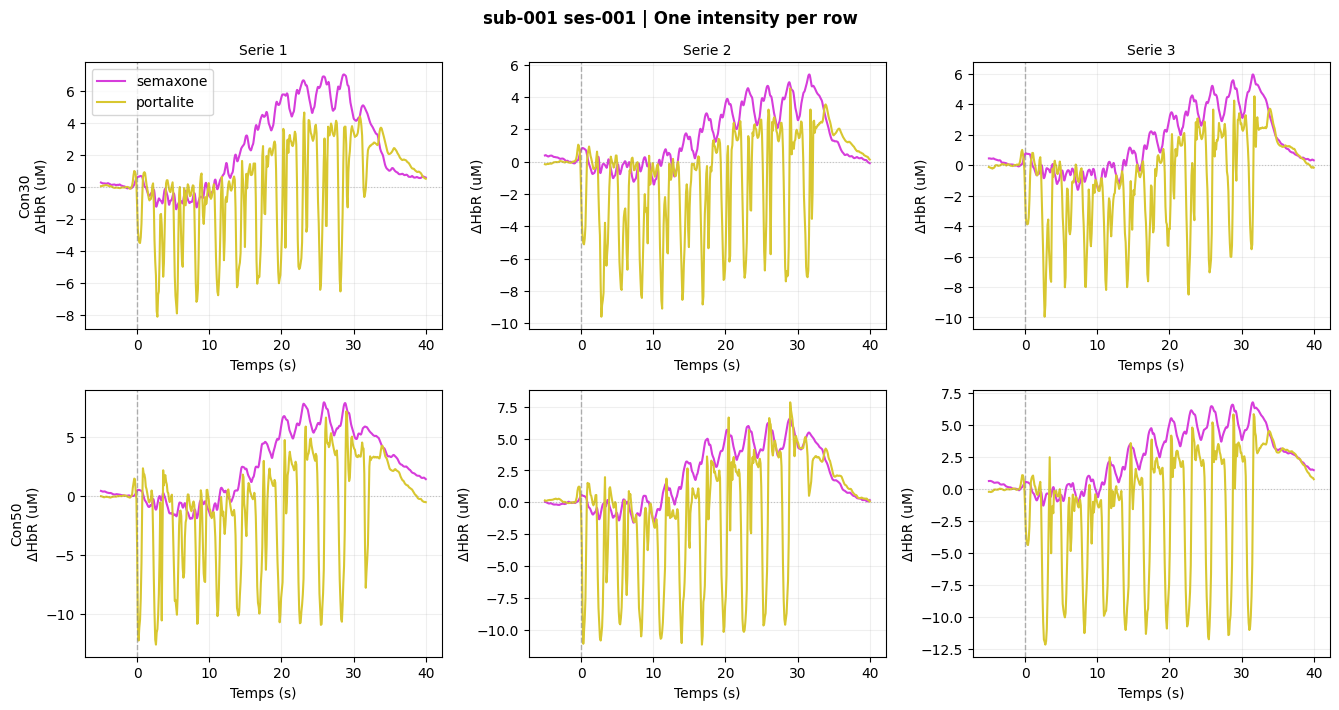

In [170]:
# Choose what you want to display
subject_choice = '001'
session_choice = '001'
recording_choice = ['semaxone', 'portalite']
task_choice = None
t_pre = 5
t_post = 40

NIRS_oxymove.display_sets_one_by_one(
    subject_choice=subject_choice,
    session_choice=session_choice,
    recording_choice=recording_choice,
    task_choice=task_choice,
    t_pre=t_pre,
    t_post=t_post,
    base_root=BASE_ROOT,
)

Running comparison for 24 subject(s)...

################################################################################
SUBJECT 001
################################################################################

PROCESSING CONCENTRIC DATA - SEMAXONE (ses-001)

Processing Con30 series (semaxone)...
  Series 1: Mean HbR = 0.846 µM
  Series 2: Mean HbR = 0.319 µM
  Series 3: Mean HbR = 0.153 µM

Processing Con50 series (semaxone)...
  Series 1: Mean HbR = 0.466 µM
  Series 2: Mean HbR = 0.618 µM
  Series 3: Mean HbR = 0.297 µM

PROCESSING CONCENTRIC DATA - PORTALITE (ses-001)

Processing Con30 series (portalite)...
  Series 1: Mean HbR = -0.641 µM
  Series 2: Mean HbR = -0.846 µM
  Series 3: Mean HbR = -0.814 µM

Processing Con50 series (portalite)...
  Series 1: Mean HbR = -1.147 µM
  Series 2: Mean HbR = -1.128 µM
  Series 3: Mean HbR = -1.355 µM

PROCESSING ECCENTRIC DATA - SEMAXONE (ses-002)

Processing Ecc30 series (semaxone)...
  Series 1: Mean HbR = -0.021 µM
  Series 2: Mean H

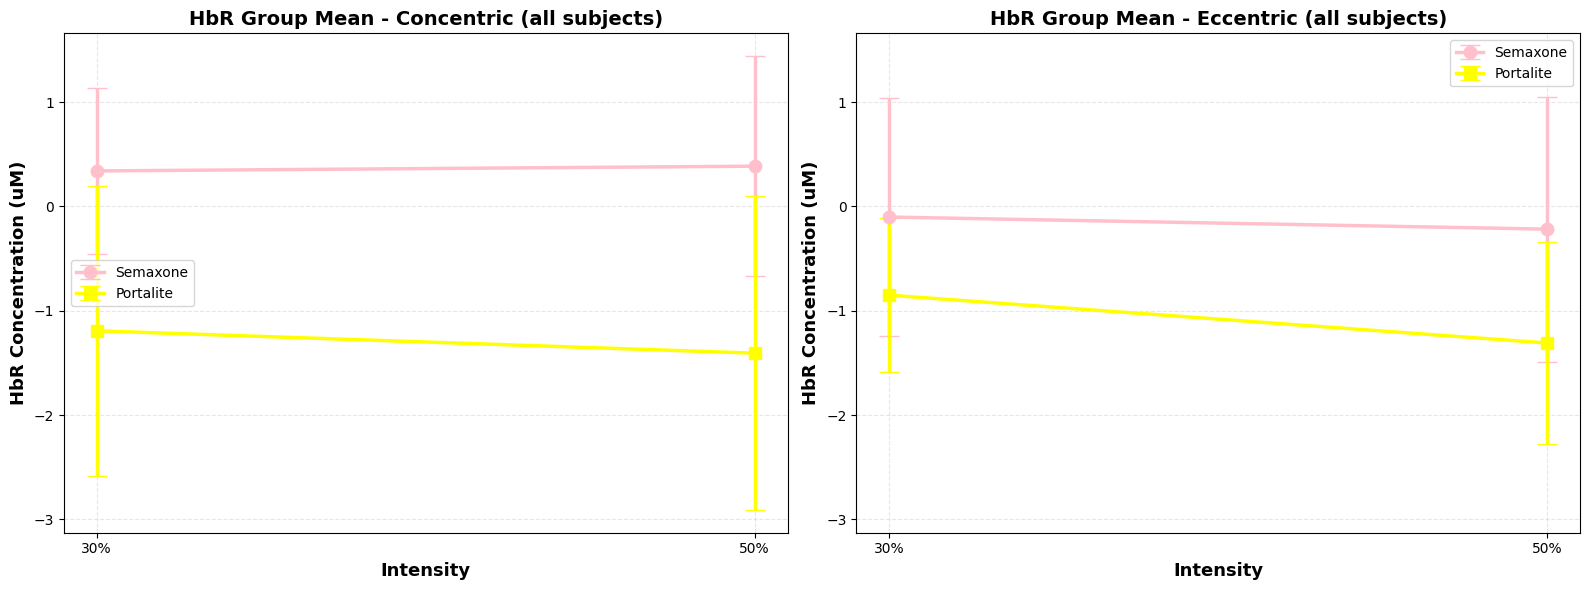

Subjects used for group mean: ['001', '002', '003', '004', '005', '006', '007', '008', '009', '010', '011', '012', '013', '014', '015', '016', '017', '018', '019', '020', '021', '022', '023', '024']

GROUP STATISTICS - HbR mean across subjects
CONCENTRIC - SEMAXONE: 30%=0.341+-0.799 (n=23), 50%=0.386+-1.056 (n=23)
CONCENTRIC - PORTALITE: 30%=-1.192+-1.390 (n=23), 50%=-1.406+-1.504 (n=23)
ECCENTRIC - SEMAXONE: 30%=-0.101+-1.137 (n=20), 50%=-0.217+-1.271 (n=19)
ECCENTRIC - PORTALITE: 30%=-0.850+-0.740 (n=22), 50%=-1.309+-0.965 (n=21)


In [171]:
group_stats = NIRS_oxymove.compare_devices_group_mean(
    subject_ids=None,  # None = all subjects found in BASE_ROOT
    base_root=BASE_ROOT,
    intensities=intensities,
    make_plot=True,
    print_stats=True,
)

# Keep variables available for downstream cells
globals().update(group_stats)

## Plotting the enveloppe and the air under the curve for each set

Using events file: C:\Program Files\DigiMove\DigiMove\DataAnalysisProject\data\MOXY-bids\sub-001\ses-001\nirs\sub-001_ses-001_task-concentric_events.tsv


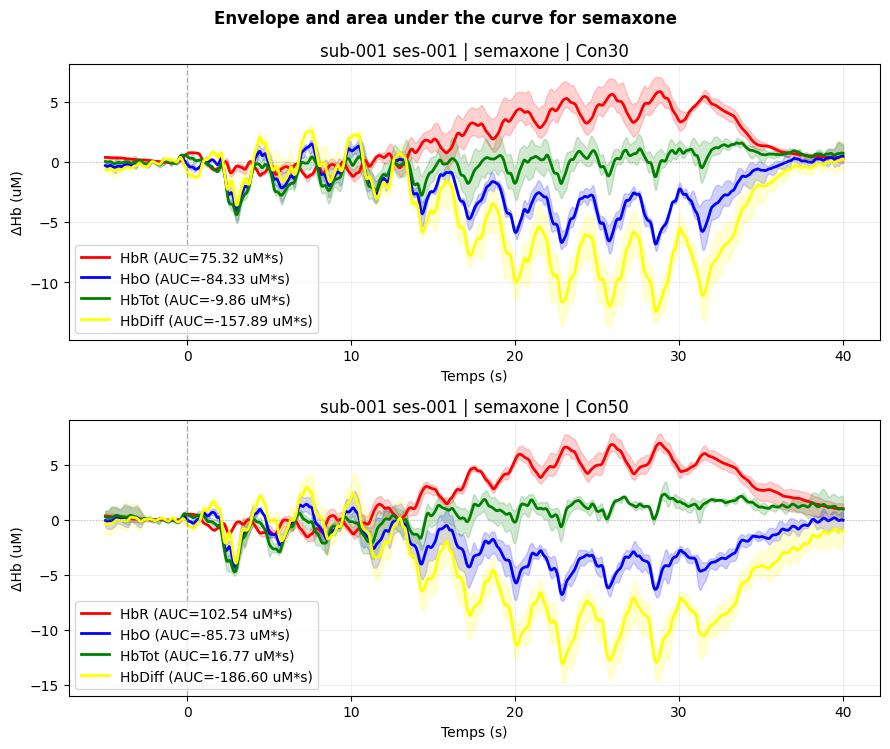

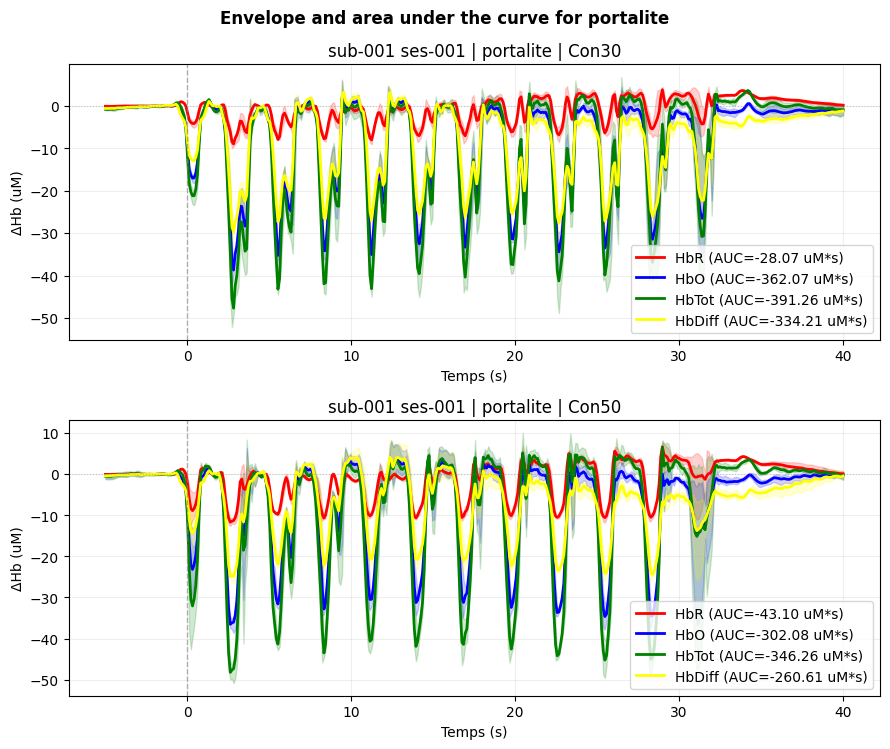

In [172]:
hb_summary = NIRS_oxymove.plot_hb_envelope_and_auc_per_set(
    subject_choice=subject_choice,
    session_choice=session_choice,
    recording_choice=recording_choice,
    task_choice=task_choice,
    t_pre=t_pre,
    t_post=t_post,
    auc_window=(0, None),
    envelope_mode='minmax',
    use_abs_auc=False,
    chromophores=('HbR', 'HbO', 'HbTot', 'HbDiff'),
    plot_mode='by_device',
    base_root=BASE_ROOT,
)

## creating a csv file for both device

In [173]:
import importlib

# Ensure the latest version of NIRS_functions_Oxymove.py is loaded in this kernel
NIRS_oxymove = importlib.reload(NIRS_oxymove)

csv_exports = NIRS_oxymove.export_hb_summary_csv_by_device(
    subject_ids=None,
    base_root=BASE_ROOT,
    recordings=['portalite', 'semaxone'],
    window_duration=window_duration,
    output_dir=None,
    filename_prefix='hb_summary_final',
    include_all_participants=True,
    print_progress=True,
)

results_df_portalite = csv_exports['portalite']['results_df']
output_path_portalite = csv_exports['portalite']['output_path']

results_df_semaxone = csv_exports['semaxone']['results_df']
output_path_semaxone = csv_exports['semaxone']['output_path']

if output_path_portalite is not None:
    print('\nPortalite table:')
    print(results_df_portalite.to_string(index=False))

if output_path_semaxone is not None:
    print('\nSemaxone table:')
    print(results_df_semaxone.to_string(index=False))

Processing sub-001 ses-001 task-concentric (portalite)
Processing sub-001 ses-002 task-eccentric (portalite)
Processing sub-002 ses-001 task-eccentric (portalite)
Processing sub-002 ses-002 task-concentric (portalite)
Processing sub-003 ses-001 task-eccentric (portalite)
Processing sub-003 ses-002 task-concentric (portalite)
Processing sub-004 ses-001 task-concentric (portalite)
Processing sub-004 ses-002 task-eccentric (portalite)
Processing sub-005 ses-001 task-concentric (portalite)
Processing sub-005 ses-002 task-eccentric (portalite)
Processing sub-006 ses-001 task-eccentric (portalite)
Processing sub-006 ses-002 task-concentric (portalite)
Processing sub-007 ses-001 task-concentric (portalite)
Processing sub-007 ses-002 task-eccentric (portalite)
Processing sub-008 ses-002 task-concentric (portalite)
Processing sub-009 ses-001 task-eccentric (portalite)
Processing sub-009 ses-002 task-concentric (portalite)
Processing sub-010 ses-001 task-concentric (portalite)
Processing sub-010